In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


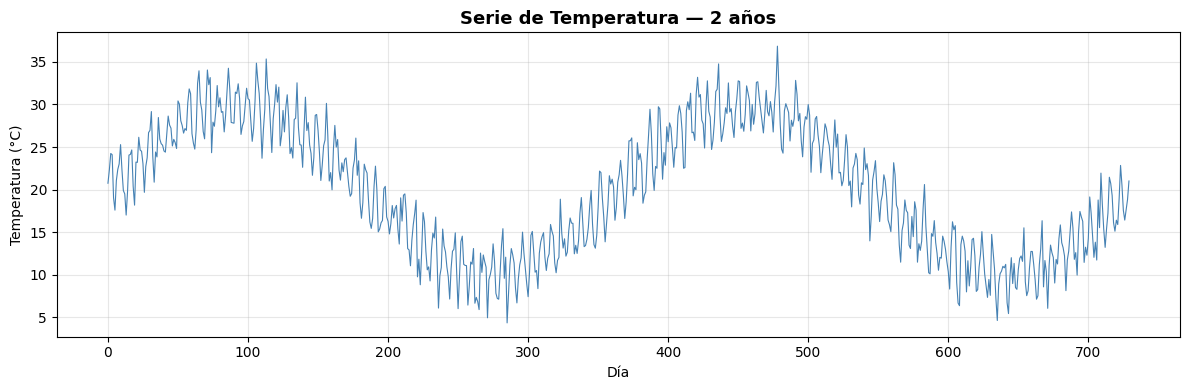

Temperatura mínima: 4.3°C
Temperatura máxima: 36.9°C
Total de días: 730


In [14]:
# Generar 730 días (2 años) de temperatura
dias = np.arange(730)

# Patrón: ciclo anual + ciclo diario leve + ruido
temperatura = (
    20                                          # temperatura base
    + 10 * np.sin(2 * np.pi * dias / 365)      # ciclo anual (verano/invierno)
    + 3  * np.sin(2 * np.pi * dias / 7)        # ciclo semanal
    + np.random.normal(0, 1.5, len(dias))       # ruido aleatorio
)

# Visualizar la serie completa
plt.figure(figsize=(12, 4))
plt.plot(dias, temperatura, color='steelblue', linewidth=0.8)
plt.title('Serie de Temperatura — 2 años', fontsize=13, fontweight='bold')
plt.xlabel('Día')
plt.ylabel('Temperatura (°C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Temperatura mínima: {temperatura.min():.1f}°C')
print(f'Temperatura máxima: {temperatura.max():.1f}°C')
print(f'Total de días: {len(temperatura)}')

In [15]:
# Normalizar: escalar los valores al rango [0, 1]
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temperatura.reshape(-1, 1))

# Crear ventanas temporales
VENTANA = 30  # Usamos 30 días para predecir el día 31

def crear_secuencias(datos, ventana):
    X, y = [], []
    for i in range(len(datos) - ventana):
        X.append(datos[i : i + ventana])      # 30 días de entrada
        y.append(datos[i + ventana])           # día 31 como objetivo
    return np.array(X), np.array(y)

X, y = crear_secuencias(temp_scaled, VENTANA)

# División: 80% entrenamiento, 20% prueba
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X_train: {X_train.shape}  →  ({X_train.shape[0]} secuencias de {VENTANA} días)')
print(f'X_test:  {X_test.shape}')

X_train: (560, 30, 1)  →  (560 secuencias de 30 días)
X_test:  (140, 30, 1)


In [16]:
# Normalizar: escalar los valores al rango [0, 1]
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temperatura.reshape(-1, 1))

# Crear ventanas temporales
VENTANA = 30  # Usamos 30 días para predecir el día 31

def crear_secuencias(datos, ventana):
    X, y = [], []
    for i in range(len(datos) - ventana):
        X.append(datos[i : i + ventana])      # 30 días de entrada
        y.append(datos[i + ventana])           # día 31 como objetivo
    return np.array(X), np.array(y)

X, y = crear_secuencias(temp_scaled, VENTANA)

# División: 80% entrenamiento, 20% prueba
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X_train: {X_train.shape}  →  ({X_train.shape[0]} secuencias de {VENTANA} días)')
print(f'X_test:  {X_test.shape}')

X_train: (560, 30, 1)  →  (560 secuencias de 30 días)
X_test:  (140, 30, 1)


In [18]:
modelo = keras.Sequential([
    # Capa LSTM: aprende patrones en la secuencia de 30 días
    layers.LSTM(64, input_shape=(VENTANA, 1), return_sequences=False),
    layers.Dropout(0.2),       # Regularización
    layers.Dense(32, activation='relu'),
    layers.Dense(1)            # Predice 1 valor: la temperatura del día siguiente
])

modelo.compile(
    optimizer='adam',
    loss='mse',                # Error cuadrático medio
    metrics=['mae']            # Error absoluto medio (más fácil de interpretar)
)

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# EarlyStopping: detiene el entrenamiento si no mejora (evita sobreajuste)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

historial = modelo.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1)

print(f'\nEpocas entrenadas: {len(historial.history["loss"])}')

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0102 - mae: 0.0827 - val_loss: 0.0078 - val_mae: 0.0713
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0098 - mae: 0.0796 - val_loss: 0.0078 - val_mae: 0.0714
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0111 - mae: 0.0853 - val_loss: 0.0078 - val_mae: 0.0715
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0099 - mae: 0.0804 - val_loss: 0.0078 - val_mae: 0.0728
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0108 - mae: 0.0823 - val_loss: 0.0079 - val_mae: 0.0737
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0105 - mae: 0.0823 - val_loss: 0.0078 - val_mae: 0.0724
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0100 - mae: 0.0817 - val_loss: 0.0079 - val_mae: 0.0731
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0094 - mae: 0.0791 - val_loss: 0.0078 - val_mae: 0.0717

Epocas entrenadas: 8


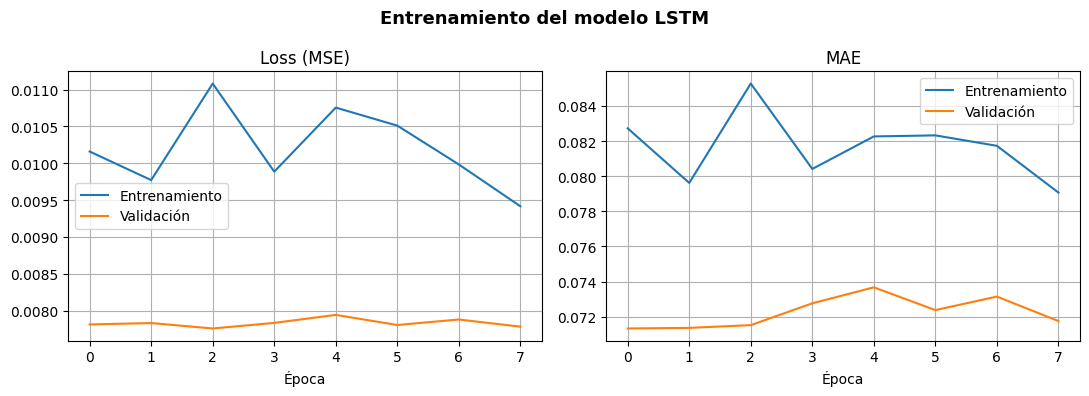

In [22]:
# Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Entrenamiento del modelo LSTM', fontsize=13, fontweight='bold')

ax1.plot(historial.history['loss'],     label='Entrenamiento')
ax1.plot(historial.history['val_loss'], label='Validación')
ax1.set_title('Loss (MSE)'); ax1.set_xlabel('Época')
ax1.legend(); ax1.grid(True)

ax2.plot(historial.history['mae'],     label='Entrenamiento')
ax2.plot(historial.history['val_mae'], label='Validación')
ax2.set_title('MAE'); ax2.set_xlabel('Época')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# Predecir en el conjunto de prueba
pred_scaled = modelo.predict(X_test, verbose=0)

# Revertir la normalización para obtener °C reales
pred_real = scaler.inverse_transform(pred_scaled)
real_real = scaler.inverse_transform(y_test)

# Métricas
mae  = mean_absolute_error(real_real, pred_real)
rmse = np.sqrt(mean_squared_error(real_real, pred_real))

print('=' * 40)
print(f'  MAE  (Error Absoluto Medio): {mae:.2f} °C')
print(f'  RMSE (Raíz Error Cuadrático): {rmse:.2f} °C')
print('=' * 40)
print('→ El modelo se equivoca en promedio', f'{mae:.2f}°C')

  MAE  (Error Absoluto Medio): 2.25 °C
  RMSE (Raíz Error Cuadrático): 2.76 °C
→ El modelo se equivoca en promedio 2.25°C


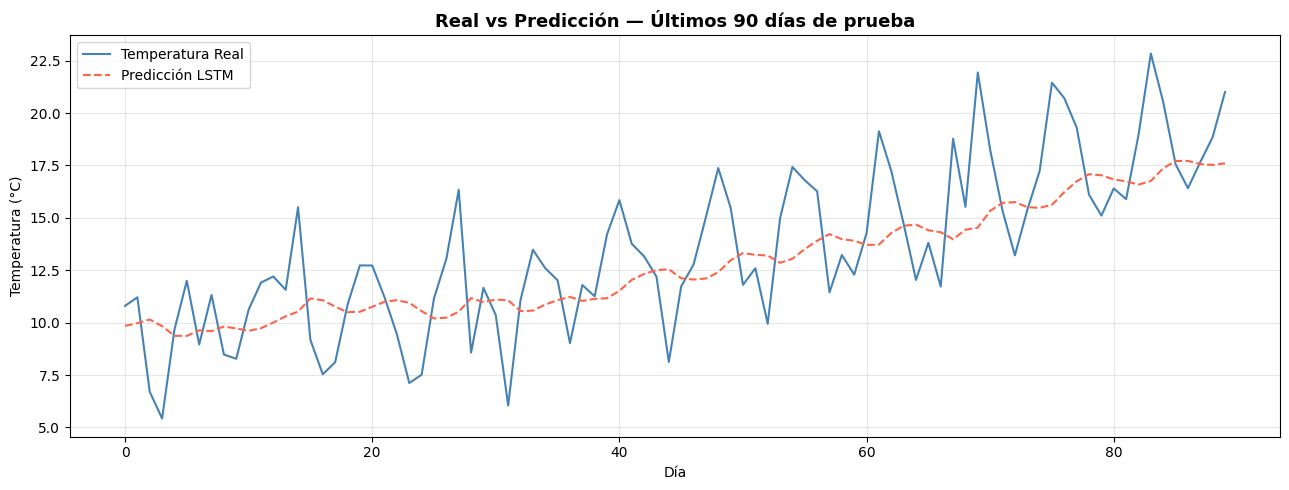

In [24]:
# Visualización: real vs predicción (últimos 90 días)
plt.figure(figsize=(13, 5))
plt.plot(real_real[-90:], label='Temperatura Real',    color='steelblue', linewidth=1.5)
plt.plot(pred_real[-90:], label='Predicción LSTM',     color='tomato',    linewidth=1.5, linestyle='--')
plt.title('Real vs Predicción — Últimos 90 días de prueba', fontsize=13, fontweight='bold')
plt.xlabel('Día')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

¿Qué aprendió el modelo?
La LSTM capturó correctamente el patrón estacional de la temperatura. Las predicciones siguen la tendencia general de subida y bajada, lo que confirma que el modelo aprendió la dependencia temporal.

¿Dónde falla?
Los picos bruscos generados por el ruido aleatorio son difíciles de predecir — ningún modelo puede anticipar valores completamente aleatorios. Esto es esperado.

Sobreajuste:
El uso de EarlyStopping y Dropout evitó que el modelo memorizara el entrenamiento. Si las curvas de loss de entrenamiento y validación son cercanas, el modelo generaliza bien.